In [1]:
from abc import ABC, abstractmethod
import VanDerCorputSeq as vdcsq
import numpy as np
import random as rng
import matplotlib.pyplot as plt
import time

In [2]:
import random

class MersenneTwister(vdcsq.RandomNumberGenerator1D):
    def __init__(self, seed=None):
        if seed is not None:
            self.seed = seed
            self.generator = random.Random(seed)
        else:
            self.seed = random.getrandbits(64)
            self.generator = random.Random(self.seed)

    def nextDouble(self):
        return self.generator.random()

    def nextDoubleFast(self):
        return self.generator.random()

    def __str__(self):
        return f"MersenneTwister [seed={self.seed}]"

In [3]:
#Interface
class randomNumberGenerator(ABC):
    @abstractmethod
    def getNext(self):
        pass

    @abstractmethod
    def getDimension(self):
        pass

In [4]:
class RandomNumberGeneratorFrom1D(randomNumberGenerator):
    randomNumberGenerator = None
    dimension = 0

    def __init__(self, randomNumberGenerator, dimension):
        self.randomNumberGenerator = randomNumberGenerator
        self.dimension = dimension

    def getNext(self):
        value = [None]*self.dimension
        for i in range(self.dimension):
            value[i] = self.randomNumberGenerator.nextDouble()
        return value
    
    def getDimension(self):
        return self.dimension

In [5]:
class RandomNumberGenerator2DExperiment:    
    def plotSamplePoints(self, generator, name = ''):
        points = []
        for i in range(1000):
            point = generator.getNext()
            points.append(point)

        x = [p[0] for p in points]
        y = [p[1] for p in points]

        plt.figure(figsize=(10, 5))
        plt.scatter(x, y, s=3)
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.title(f'{name} {str(generator)}')
        
        safe_filename = f"plot_{int(time.time())}.png"
        plt.savefig(safe_filename)
        plt.show()
    
    def __init__(self):
        generatorPseudo = RandomNumberGeneratorFrom1D(MersenneTwister(3141), 2)
        self.plotSamplePoints(generatorPseudo, name = 'Pseudoaleatorio (MersenneTwister)')

        generatorQuasiWrong = RandomNumberGeneratorFrom1D(vdcsq.VanDerCorputSequence(2), 2)
        self.plotSamplePoints(generatorQuasiWrong, name= 'Quasi (Van Der Corput Sequence)')

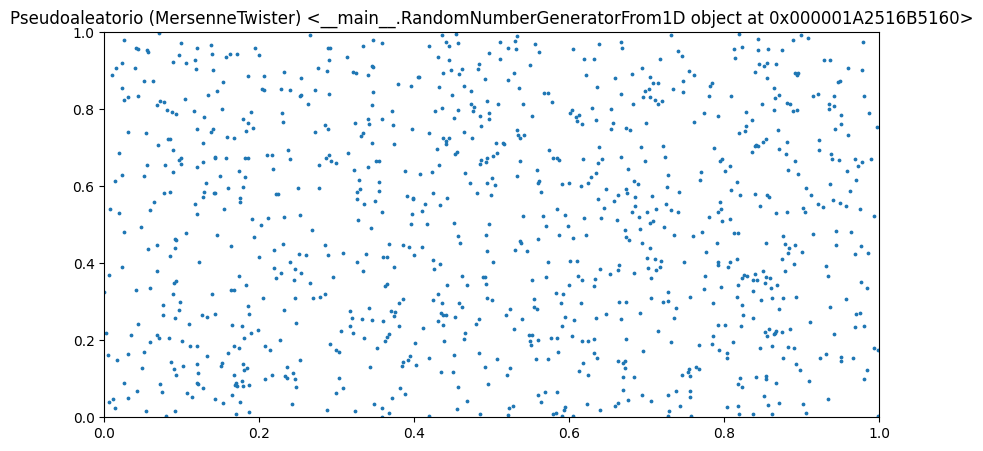

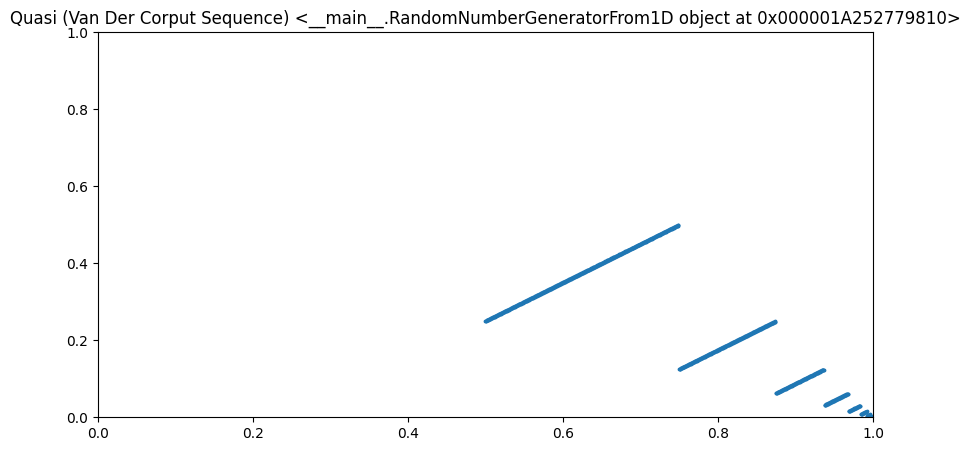

In [6]:
a = RandomNumberGenerator2DExperiment()

### **PROBLEMS WITH VAND DER CORPUT SEQUENCE**
- To avoid the problems with the curse of dimensionality, there are an assumption that we need to complete, that is, the sequence should be independent and identically distributed(i.i.d).
- With VDC sequence we have an structure that is not i.i.d..
- So, we need to solve it, we need a *Low discrepancy sequence (Multi-Dimensional)*

In [7]:
import threading
class AtomicLong:
    def __init__(self, initial=0):
        self._value = initial
        self._lock = threading.Lock()

    def get(self):
        with self._lock:
            return self._value

    def getAndIncrement(self):
        with self._lock:
            current = self._value
            self._value += 1
            return current

# **HALTON SEQUENCE:**
- **DEFINITION:**
- Still related to the VDC sequence, is an extensions of it; but it introduces the use of independent VDC sequences for each dimension where the base of each is different and *aquo prime*.
- So, the bases are $b_1, ..., b_d \in \mathbb{N}$ \ $\{1\}$ such that $b_j, b_k$ have greatest common divisor 1 for $j \ne k$
- The sequence $\{X_i\}_{i \in \mathbb{N}} \subset [0, 1]^d$ is called ***Halton sequence*** with bases $b_1, ..., b_d \in \mathbb{N}$ if $\{X_i\}_{i \in \mathbb{N}} \subset (0, 1)$ (where $x_{i, j}$ is the j-th component of $x_i$ is a Vander Corpurt sequence with base $b_j.$))


> We can estimate the *Halton sequence star discrepancy:*
>$$
>D^*(x_1, ..., x_n) = C \cdot \frac{(\log(n))^d}{n}
>$$
> C dependes only on the choice of the basis $b_1, ..., b_d$

> `We can note that it becomes worse as the dimension increases`

> Comparision between ***TRADITIONAL MONTE CARLO VS QUASI MONTE CARLO***

### **Remark 47 (The Convergence Rate in Practical Applications)**

How does the convergence rate  
$$
\frac{(\log(n))^d}{n}
$$  
of a quasi Monte-Carlo method compare to the convergence rate of the classical Monte-Carlo method  
$$
\frac{1}{\sqrt{n}}
$$  
for a practical choice of \( n \)? Note that:

$$
\frac{(\log(n))^d}{n} \leq \frac{1}{\sqrt{n}} 
\iff (\log(n))^d \leq \sqrt{n} 
\iff d \log(\log(n)) \leq \log(\sqrt{n}) 
\iff d \leq \frac{1}{2} \cdot \frac{\log(n)}{\log(\log(n))}.
$$

Of course, since we only know that the convergence is of that *order*, and do not know the constant in the error estimate, we cannot make a precise statement based on this estimate.

However, note that for \( n = 1,000,000 \), we find (with \( \log = \log_{10} \)):

$$
\frac{1}{2} \cdot \frac{\log(n)}{\log(\log(n))} \approx 4.1.
$$

`Hence, we may expect that the classical (random) Monte-Carlo method performs better in higher dimensions (d>4)`

> Also, we can see the ***SOBOL Method*** that is also famous

In [8]:
class HaltonSequence(randomNumberGenerator):
    base = []
    def __init__(self, base):
        super().__init__()
        self.base = base
        self.index = AtomicLong(0)

    def getNext(self):
        value = [None]*len(self.base)
        currentIndex = self.index.getAndIncrement()
        for i in range(len(self.base)):
            value[i] = vdcsq.VanDerCorputSequence.getVanDerCorputNumber(currentIndex, self.base[i])
        return value
    
    def getDimension(self):
        return len(self.base)
    

In [9]:
class RandomNumberGenerator2DExperiment:    
    def plotSamplePoints(self, generator, name = ''):
        points = []
        for i in range(1000):
            point = generator.getNext()
            points.append(point)

        x = [p[0] for p in points]
        y = [p[1] for p in points]

        plt.figure(figsize=(10, 5))
        plt.scatter(x, y, s=3)
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.title(f'{name} {str(generator)}')
        
        safe_filename = f"plot_{int(time.time())}.png"
        plt.savefig(safe_filename)
        plt.show()
    
    def __init__(self):
        generatorPseudo = RandomNumberGeneratorFrom1D(MersenneTwister(3141), 2)
        self.plotSamplePoints(generatorPseudo, name = 'Pseudoaleatorio (MersenneTwister)')

        generatorQuasiWrong = RandomNumberGeneratorFrom1D(vdcsq.VanDerCorputSequence(2), 2)
        self.plotSamplePoints(generatorQuasiWrong, name= 'QuasiWrong (Van Der Corput Sequence)')

        generatorQuasi = HaltonSequence([2, 3])
        self.plotSamplePoints(generatorQuasi, name= 'Quasi (Halton Sequece)')

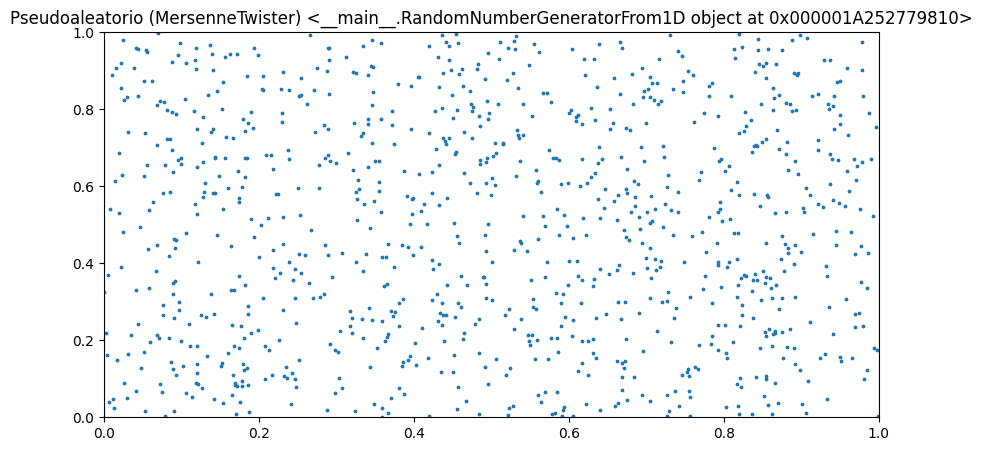

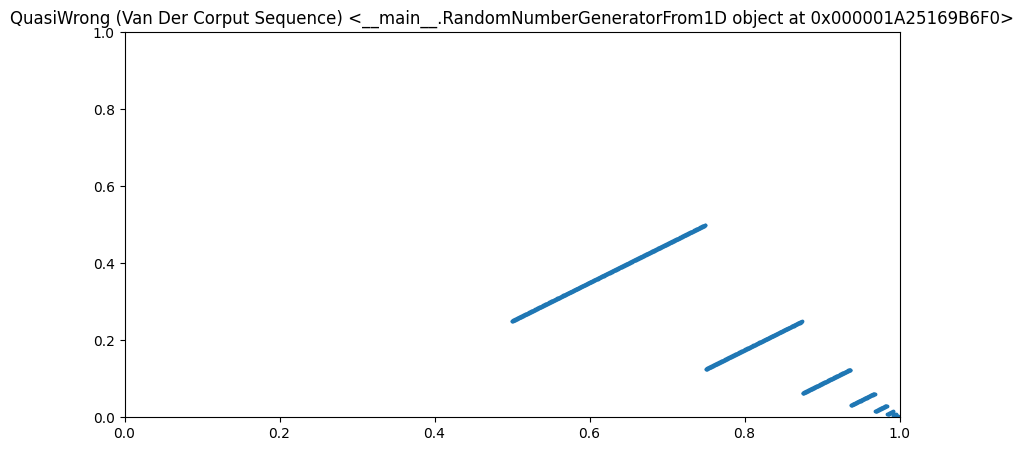

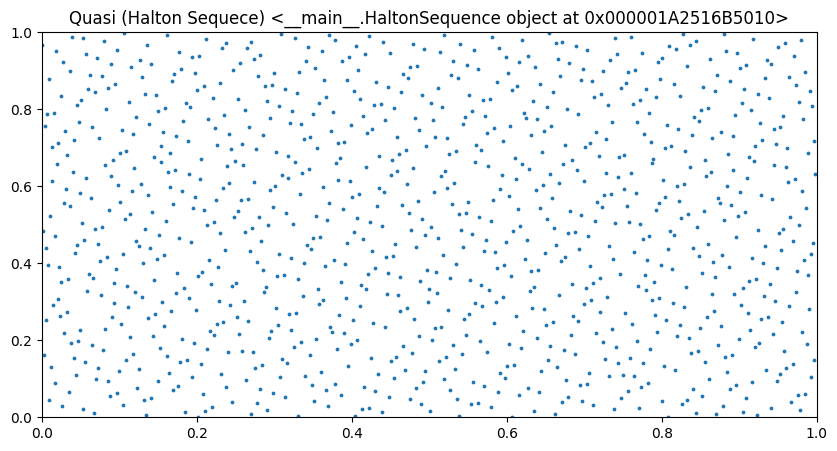

In [10]:
b = RandomNumberGenerator2DExperiment()